# MARCH MADNESS 2026 

## XGBoost
We'll start with an XGBoost (Extreme Gradient Boost) Model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import metrics
import xgboost as xgb
import math

## Pull Relavent Data from Kaggle 2026 March Madness Database

Here we'll pull, clean, and extrapolate relavent data to train our model with

In [2]:
#Load Data
regularSeason = pd.read_csv("Men's Dataset\MRegularSeasonDetailedResults.csv")
pastTourneyData = pd.read_csv("Men's Dataset\MNCAATourneyCompactResults.csv")
teams = pd.read_csv("Men's Dataset/MTeams.csv")
team_dict = teams.set_index('TeamID')['TeamName'].to_dict()
seedsRaw = pd.read_csv("Men's Dataset/MNCAATourneySeeds.csv")
#Extract only the numbers
seedsRaw['Seed_Int'] = seedsRaw['Seed'].str.extract('(\d+)').astype(int)
seeds = seedsRaw[['Season', 'TeamID', 'Seed_Int']]

#Estimate Posessions 
#FGA - OR + TO + (0.475 * FTA)
#Field Goal Attempts - Offensive Rebounds + Turnovers + 47.5% of Free Throw Attempts (Generally Accepted number of free throws that end possesion)
regularSeason['WPoss'] = regularSeason['WFGA'] - regularSeason['WOR'] + regularSeason['WTO'] + (0.475 * regularSeason['WFTA'])
regularSeason['LPoss'] = regularSeason['LFGA'] - regularSeason['LOR'] + regularSeason['LTO'] + (0.475 * regularSeason['LFTA'])

#Offensive Efficiency
#(Score / Poss)
#Points per possession (higher better)
regularSeason['WOEff'] = (regularSeason['WScore'] / regularSeason['WPoss'])
regularSeason['LOEff'] = (regularSeason['LScore'] / regularSeason['LPoss'])

#Deffensive Efficiency
#Opp(Score / Poss)
#Opponent Point per possession (lower better)
regularSeason['WDEff'] = (regularSeason['LScore'] / regularSeason['LPoss'])
regularSeason['LDEff'] = (regularSeason['WScore'] / regularSeason['WPoss'])

#Net Rating
#Offensive Efficiency - Deffensive Efficiency
#This gives us the point differential per possesions (higher better)
regularSeason['WNRtg'] = regularSeason['WOEff'] - regularSeason['WDEff']
regularSeason['LNRtg'] = regularSeason['LOEff'] - regularSeason['LDEff']

#Effective Field Goal Percentage
#eFG% = (FGM + 0.5 * FGM3) / FGA
#Field Goals Made + 50% of 3-Pointers Made, divided by Total Field Goal Attempts
regularSeason['WEFG'] = (regularSeason['WFGM'] + 0.5 * regularSeason['WFGM3']) / regularSeason['WFGA']
regularSeason['LEFG'] = (regularSeason['LFGM'] + 0.5 * regularSeason['LFGM3']) / regularSeason['LFGA']

#Turnover Percentage
#TO / Team Possesions
#Percentage of posessions that end in turnovers
regularSeason['WTO%'] = (regularSeason['WTO'] / regularSeason['WPoss'])
regularSeason['LTO%'] = (regularSeason['LTO'] / regularSeason['LPoss'])

#Offensive Rebound Percentage
#Offensive Rebound / (Offensive Rebound + Opponent Deffensive Rebound)
#Percentage of offensive rebounds won by team
regularSeason['WORb%'] = (regularSeason['WOR'] / (regularSeason['WOR'] + regularSeason['LDR']))
regularSeason['LORb%'] = (regularSeason['LOR'] / (regularSeason['LOR'] + regularSeason['WDR']))

#Defensive Rebound Percentage
#Defensive Rebound / (Defensive Rebound + Opponent Offensive Rebound)
#Percentage of defensive rebounds won by team
regularSeason['WDRb%'] = (regularSeason['WDR'] / (regularSeason['WDR'] + regularSeason['LOR']))
regularSeason['LDRb%'] = (regularSeason['LDR'] / (regularSeason['LDR'] + regularSeason['WOR']))

#Free Throw Rate
#Free Throw Attempts / Field Goal Attempts
#Indicates pace and efficiency in drawing fouls
regularSeason['WFT%'] = (regularSeason['WFTA'] / regularSeason['WFGA'])
regularSeason['LFT%'] = (regularSeason['LFTA'] / regularSeason['LFGA'])

#True Shooting Percentage
#Team Score / (2 * (FGA + 0.44 * FTA))
#Gives us overarching shooting accuracy 
regularSeason['WTS%'] = (regularSeason['WScore'] / (2 * (regularSeason['WFGA'] + 0.44 * regularSeason['WFTA'])))
regularSeason['LTS%'] = (regularSeason['LScore'] / (2 * (regularSeason['LFGA'] + 0.44 * regularSeason['LFTA'])))

#3-Point Attempt Percentage
#FGA3 / FGA
#Tells us how often a team shoots from 3
regularSeason['W3PA%'] = (regularSeason['WFGA3'] / regularSeason['WFGA'])
regularSeason['L3PA%'] = (regularSeason['LFGA3'] / regularSeason['LFGA'])

#Assist Percentage
#Assists / FGM
#Tells us how much a team moves the ball before scoring
regularSeason['WAst%'] = (regularSeason['WAst'] / regularSeason['WFGM'])
regularSeason['LAst%'] = (regularSeason['LAst'] / regularSeason['LFGM'])

#Steal Percentage
#(Steal / Opponent Possesion)
#Defensive steals rate
regularSeason['WStl%'] = (regularSeason['WStl'] / regularSeason['LPoss'])
regularSeason['LStl%'] = (regularSeason['LStl'] / regularSeason['WPoss'])

#Block Percentage
#(Blocks / Opponent FGA)
#Rate of defensive shot blocks
regularSeason['WBlk%'] = (regularSeason['WBlk'] / regularSeason['LFGA'])
regularSeason['LBlk%'] = (regularSeason['LBlk'] / regularSeason['WFGA'])

#Assist To Turn Over Ration
#Assists / TO
#Ratio of Assists to Offensive Turnovers (Ideally 2:1)
regularSeason['WAstTOR'] = (regularSeason['WAst'] / regularSeason['LTO'])
regularSeason['LAstTOR'] = (regularSeason['LAst'] / regularSeason['WTO'])

## Separate Data By Team

Here we'll distinguish the winners and the losers so that the model knows which team won 

The data will also be distinguished by the season and team so that we can compare teams of the same year (thus bypassing differences in playstyle from 1985 to today)

In [3]:
#Winners data
W_cols = ['Season', 'WTeamID', 'WPoss', 'WOEff', 'WDEff', 'WNRtg', 'WEFG', 'WTO%', 'WORb%', 'WDRb%', 'WFT%', 'WTS%', 'W3PA%', 'WAst%', 'WStl%', 'WBlk%', 'WAstTOR']
winners = regularSeason[W_cols].copy()
winners.columns = ['Season', 'TeamID', 'Poss', 'OEff', 'DEff', 'NRtg', 'EFG', 'TO%', 'ORb%', 'DRb%', 'FT%', 'TS%', '3PA%', 'Ast%', 'Stl%', 'Blk%', 'AstTOR']

#Losers data
L_cols = ['Season', 'LTeamID', 'LPoss', 'LOEff', 'LDEff', 'LNRtg', 'LEFG', 'LTO%', 'LORb%', 'LDRb%', 'LFT%', 'LTS%', 'L3PA%', 'LAst%', 'LStl%', 'LBlk%', 'LAstTOR']
losers = regularSeason[L_cols].copy()
losers.columns = ['Season', 'TeamID', 'Poss', 'OEff', 'DEff', 'NRtg', 'EFG', 'TO%', 'ORb%', 'DRb%', 'FT%', 'TS%', '3PA%', 'Ast%', 'Stl%', 'Blk%', 'AstTOR']

#Concat into one list
matches = pd.concat([winners, losers], ignore_index=True)
seasonAvgs = matches.groupby(['Season', 'TeamID']).mean().reset_index()

## Randomize Team Order And Prepare Data

To make sure the model doesn't create a correlation with the first team always winning, we'll randomize the teams by making the first team the lower value ID number (this is an arbitrary rng mechanic)
We'll also define the training features as differences in the teams values

In [4]:
pastTourneyData['Team1'] = np.where(pastTourneyData['WTeamID'] < pastTourneyData['LTeamID'], pastTourneyData['WTeamID'], pastTourneyData['LTeamID'])
pastTourneyData['Team2'] = np.where(pastTourneyData['WTeamID'] > pastTourneyData['LTeamID'], pastTourneyData['WTeamID'], pastTourneyData['LTeamID'])
pastTourneyData['Target_Diff'] = np.where(pastTourneyData['WTeamID'] == pastTourneyData['Team1'], pastTourneyData['WScore'] - pastTourneyData['LScore'], pastTourneyData['LScore'] - pastTourneyData['WScore']) 

dataset = pd.merge(pastTourneyData, seasonAvgs, left_on= ['Season', 'Team1'], right_on=['Season', 'TeamID'], how='left')
dataset = dataset.rename(columns={'Poss': 'T1_Poss', 'OEff': 'T1_OEff', 'DEff': 'T1_DEff', 'NRtg': 'T1_NRtg', 'EFG': 'T1_EFG', 'TO%': 'T1_TO%', 'ORb%': 'T1_ORb%', 'DRb%': 'T1_DRb%', 'FT%': 'T1_FT%', 'TS%': 'T1_TS%', '3PA%': 'T1_3PA%', 'Ast%': 'T1_Ast%', 'Stl%': 'T1_Stl%', 'Blk%': 'T1_Blk%', 'AstTOR': 'T1_AstTOR'})
dataset = dataset.drop('TeamID', axis=1)

dataset = pd.merge(dataset, seasonAvgs, left_on= ['Season', 'Team2'], right_on=['Season', 'TeamID'], how='left')
dataset = dataset.rename(columns={'Poss': 'T2_Poss', 'OEff': 'T2_OEff', 'DEff': 'T2_DEff', 'NRtg': 'T2_NRtg', 'EFG': 'T2_EFG', 'TO%': 'T2_TO%', 'ORb%': 'T2_ORb%', 'DRb%': 'T2_DRb%', 'FT%': 'T2_FT%', 'TS%': 'T2_TS%', '3PA%': 'T2_3PA%', 'Ast%': 'T2_Ast%', 'Stl%': 'T2_Stl%', 'Blk%': 'T2_Blk%', 'AstTOR': 'T2_AstTOR'})
dataset = dataset.drop('TeamID', axis=1)

dataset = pd.merge(dataset, seeds, 
                   left_on=['Season', 'Team1'], 
                   right_on=['Season', 'TeamID'], 
                   how='left')
dataset = dataset.rename(columns={'Seed_Int': 'Team1Seed'})
dataset = dataset.rename(columns={'TeamID':'Team1ID' }) 
dataset = dataset.drop('DayNum', axis=1)

dataset = pd.merge(dataset, seeds, 
                   left_on=['Season', 'Team2'], 
                   right_on=['Season', 'TeamID'], 
                   how='left')
dataset = dataset.rename(columns={'Seed_Int': 'Team2Seed'})
dataset = dataset.rename(columns={'TeamID': 'Team2ID' })

dataset['Poss_Diff'] = dataset['T1_Poss'] - dataset['T2_Poss']
dataset['OEff_Diff'] = dataset['T1_OEff'] - dataset['T2_OEff']
dataset['DEff_Diff'] = dataset['T1_DEff'] - dataset['T2_DEff']
dataset['NRtg_Diff'] = dataset['T1_NRtg'] - dataset['T2_NRtg']
dataset['EFG_Diff'] = dataset['T1_EFG'] - dataset['T2_EFG']
dataset['FT%_Diff'] = dataset['T1_FT%'] - dataset['T2_FT%']
dataset['TS%_Diff'] = dataset['T1_TS%'] - dataset['T2_TS%']
dataset['3PA%_Diff'] = dataset['T1_3PA%'] - dataset['T2_3PA%']
dataset['TO%_Diff'] = dataset['T1_TO%'] - dataset['T2_TO%']
dataset['ORb%_Diff'] = dataset['T1_ORb%'] - dataset['T2_ORb%']
dataset['DRb%_Diff'] = dataset['T1_DRb%'] - dataset['T2_DRb%']
dataset['Ast%_Diff'] = dataset['T1_Ast%'] - dataset['T2_Ast%']
dataset['Stl%_Diff'] = dataset['T1_Stl%'] - dataset['T2_Stl%']
dataset['Blk%_Diff'] = dataset['T1_Blk%'] - dataset['T2_Blk%']
dataset['AstTOR_Diff'] = dataset['T1_AstTOR'] - dataset['T2_AstTOR']
dataset['Seed_Diff'] = dataset['Team1Seed'] - dataset['Team2Seed']

## Prep And Train The Model
Training variables are defined and a cap on score differentials is set, a score margin of 25+ is considered equal as a team winning by 25 points is still dominant and anything more is going to mess up the models training

In [5]:
features = [
    'Poss_Diff', 'OEff_Diff', 'DEff_Diff', 'NRtg_Diff', 'EFG_Diff', 
    'TO%_Diff', 'ORb%_Diff', 'DRb%_Diff', 'FT%_Diff', 'TS%_Diff', 
    '3PA%_Diff', 'Ast%_Diff', 'Stl%_Diff', 'Blk%_Diff', 'AstTOR_Diff', 'Seed_Diff'
]

x = dataset[features]
y = dataset['Target_Diff']
y_capped = np.clip(y, -25, 25)

## Create Model
Now we define the model's parameters. What I have written below is the product of a process of trial and error to minimize the Mean Absolute Error (MAE) and Root Squared Mean Error (RSME). 

The graphs below indicate test and training error as well as the distribution of predicted and actual scores

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y_capped, test_size=0.20, random_state=0)
model = xgb.XGBRegressor(
    objective = 'reg:squarederror',
    eval_metric = "rmse",
    tree_method = 'hist',
    max_depth=3,                
    eta = .015,    
    gamma = 2,     
    subsample = .8,
    colsample_bylevel = .8,
    reg_lambda = 5,
    n_estimators = 2000,
    min_child_weight = 3,
    early_stopping_rounds = 100 
)

eval_set = [(x_train, y_train), (x_test, y_test)]

model.fit(x_train, y_train, eval_set = eval_set, verbose=False)

results = model.evals_result()
train_rmse = results['validation_0']['rmse']
test_rmse = results['validation_1']['rmse']

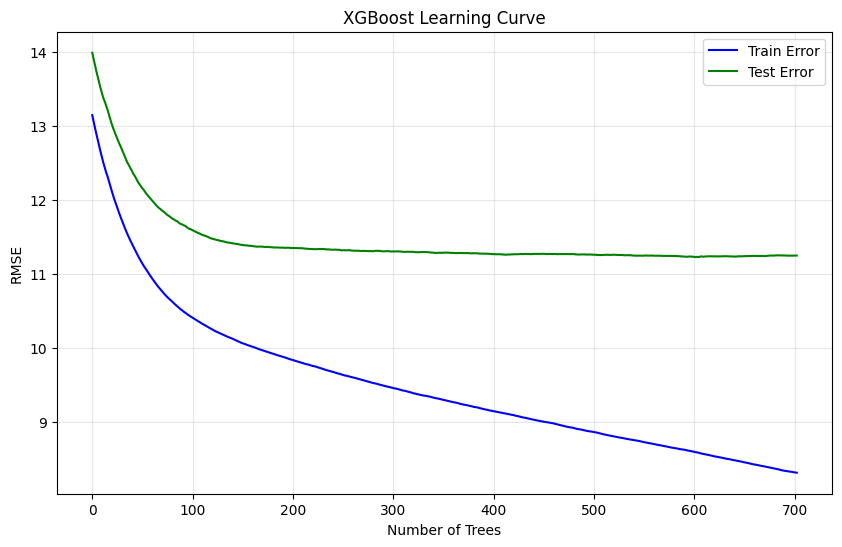

Mean Absolute Error (MAE): 9.00 points
Root Mean Squared Error (RMSE): 11.23 points


In [7]:
plt.figure(figsize=(10, 6))
plt.plot(train_rmse, label='Train Error', color='b')
plt.plot(test_rmse, label='Test Error', color='g')
plt.title('XGBoost Learning Curve')
plt.xlabel('Number of Trees')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


predictions = model.predict(x_test)

mae = metrics.mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error (MAE): {mae:.2f} points")

rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} points")

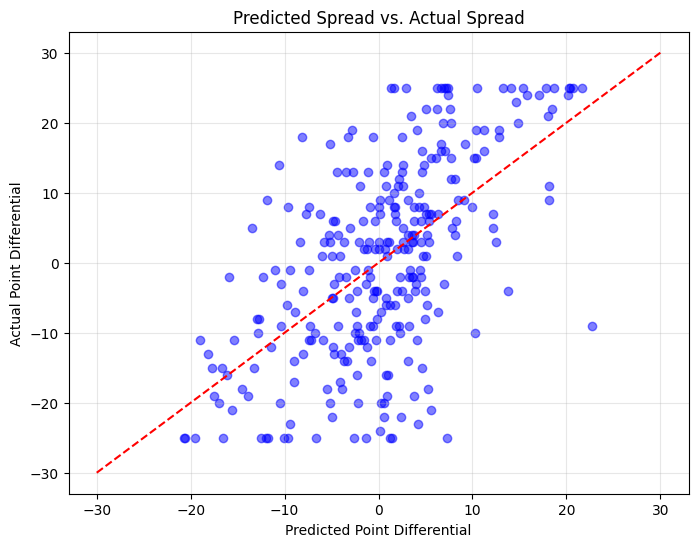

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(predictions, y_test, alpha=0.5, color='blue')

plt.plot([-30, 30], [-30, 30], color='red', linestyle='--')

plt.title('Predicted Spread vs. Actual Spread')
plt.xlabel('Predicted Point Differential')
plt.ylabel('Actual Point Differential')
plt.grid(True, alpha=0.3)
plt.show()

# March Madness 2026 XGBoost (W Seeds) Predictions

## Round of 64

In [ ]:
R64 = pd.read_csv("Men's Dataset\MR64_2026.csv")
print('Winners of the Round of 64:')
R64Winners = []
for i,row in R64.iterrows():
    id1 = int(row['Team1ID'])
    id2 = int(row['Team2ID'])

    #Pull Season Averages for the this year
    t1_stats = seasonAvgs[(seasonAvgs['Season'] == 2026) & (seasonAvgs['TeamID'] == id1)]
    t2_stats = seasonAvgs[(seasonAvgs['Season'] == 2026) & (seasonAvgs['TeamID'] == id2)]

    #Add seeds
    t1_seed = int(row['Team1Seed'])
    t2_seed = int(row['Team2Seed'])
        
    #Calculate the difference for parameters
    matchup_data = {
        'Poss_Diff': t1_stats['Poss'].iloc[0] - t2_stats['Poss'].iloc[0],
        'OEff_Diff': t1_stats['OEff'].iloc[0] - t2_stats['OEff'].iloc[0],
        'DEff_Diff': t1_stats['DEff'].iloc[0] - t2_stats['DEff'].iloc[0],
        'NRtg_Diff': t1_stats['NRtg'].iloc[0] - t2_stats['NRtg'].iloc[0],
        'EFG_Diff':  t1_stats['EFG'].iloc[0]  - t2_stats['EFG'].iloc[0],
        'TO%_Diff':  t1_stats['TO%'].iloc[0]  - t2_stats['TO%'].iloc[0],
        'ORb%_Diff': t1_stats['ORb%'].iloc[0] - t2_stats['ORb%'].iloc[0],
        'DRb%_Diff': t1_stats['DRb%'].iloc[0] - t2_stats['DRb%'].iloc[0],
        'FT%_Diff':  t1_stats['FT%'].iloc[0]  - t2_stats['FT%'].iloc[0],
        'TS%_Diff':  t1_stats['TS%'].iloc[0]  - t2_stats['TS%'].iloc[0],
        '3PA%_Diff': t1_stats['3PA%'].iloc[0] - t2_stats['3PA%'].iloc[0],
        'Ast%_Diff': t1_stats['Ast%'].iloc[0] - t2_stats['Ast%'].iloc[0],
        'Stl%_Diff': t1_stats['Stl%'].iloc[0] - t2_stats['Stl%'].iloc[0],
        'Blk%_Diff': t1_stats['Blk%'].iloc[0] - t2_stats['Blk%'].iloc[0],
        'AstTOR_Diff': t1_stats['AstTOR'].iloc[0] - t2_stats['AstTOR'].iloc[0],
        'Seed_Diff': t1_seed - t2_seed
    }

    df_predict = pd.DataFrame([matchup_data])
    df_predict = df_predict[features] 
    df_predict = df_predict.astype(float)

    predicted_spread = model.predict(df_predict)[0]

    if predicted_spread > 0:
        predWinner = id1
        predSeed = t1_seed
    else:
        predWinner = id2
        predSeed = t2_seed

    R64Winners.append({'TeamID': predWinner, 'Seed': predSeed})
    margin = abs(predicted_spread)
    winner_name = team_dict[predWinner]

    print(f'{winner_name} to win by {math.ceil(margin)} points')

R32Matches = []

for i in range(0, len(R64Winners), 2):
    TeamA = R64Winners[i]
    TeamB = R64Winners[i+1]
    R32Matches.append({
        'Team1ID': TeamA['TeamID'],
        'Team1Seed': TeamA['Seed'],
        'Team2ID': TeamB['TeamID'],
        'Team2Seed': TeamB['Seed']
    })
R32 = pd.DataFrame(R32Matches)

Winners of the Round of 64:
Duke to win by 18 points
Ohio St to win by 1 points
St John's to win by 8 points
Kansas to win by 6 points
Louisville to win by 3 points
Michigan St to win by 17 points
UCLA to win by 3 points
Connecticut to win by 16 points
Florida to win by 16 points
Clemson to win by 1 points
Vanderbilt to win by 2 points
Nebraska to win by 5 points
North Carolina to win by 4 points
Illinois to win by 20 points
St Mary's CA to win by 1 points
Houston to win by 18 points
Michigan to win by 17 points
St Louis to win by 1 points
Texas Tech to win by 5 points
Alabama to win by 6 points
Tennessee to win by 7 points
Virginia to win by 17 points
Santa Clara to win by 2 points
Iowa St to win by 16 points
Arizona to win by 17 points
Utah St to win by 2 points
Wisconsin to win by 2 points
Arkansas to win by 10 points
BYU to win by 4 points
Gonzaga to win by 14 points
Miami FL to win by 6 points
Purdue to win by 18 points


## Round of 32

In [ ]:
print('Winners of the Round of 32:')
R32Winners = []
for i,row in R32.iterrows():
    id1 = int(row['Team1ID'])
    id2 = int(row['Team2ID'])

    t1_stats = seasonAvgs[(seasonAvgs['Season'] == 2026) & (seasonAvgs['TeamID'] == id1)]
    t2_stats = seasonAvgs[(seasonAvgs['Season'] == 2026) & (seasonAvgs['TeamID'] == id2)]

    t1_seed = int(row['Team1Seed'])
    t2_seed = int(row['Team2Seed'])
        
    matchup_data = {
        'Poss_Diff': t1_stats['Poss'].iloc[0] - t2_stats['Poss'].iloc[0],
        'OEff_Diff': t1_stats['OEff'].iloc[0] - t2_stats['OEff'].iloc[0],
        'DEff_Diff': t1_stats['DEff'].iloc[0] - t2_stats['DEff'].iloc[0],
        'NRtg_Diff': t1_stats['NRtg'].iloc[0] - t2_stats['NRtg'].iloc[0],
        'EFG_Diff':  t1_stats['EFG'].iloc[0]  - t2_stats['EFG'].iloc[0],
        'TO%_Diff':  t1_stats['TO%'].iloc[0]  - t2_stats['TO%'].iloc[0],
        'ORb%_Diff': t1_stats['ORb%'].iloc[0] - t2_stats['ORb%'].iloc[0],
        'DRb%_Diff': t1_stats['DRb%'].iloc[0] - t2_stats['DRb%'].iloc[0],
        'FT%_Diff':  t1_stats['FT%'].iloc[0]  - t2_stats['FT%'].iloc[0],
        'TS%_Diff':  t1_stats['TS%'].iloc[0]  - t2_stats['TS%'].iloc[0],
        '3PA%_Diff': t1_stats['3PA%'].iloc[0] - t2_stats['3PA%'].iloc[0],
        'Ast%_Diff': t1_stats['Ast%'].iloc[0] - t2_stats['Ast%'].iloc[0],
        'Stl%_Diff': t1_stats['Stl%'].iloc[0] - t2_stats['Stl%'].iloc[0],
        'Blk%_Diff': t1_stats['Blk%'].iloc[0] - t2_stats['Blk%'].iloc[0],
        'AstTOR_Diff': t1_stats['AstTOR'].iloc[0] - t2_stats['AstTOR'].iloc[0],
        'Seed_Diff': t1_seed - t2_seed
    }

    df_predict = pd.DataFrame([matchup_data])
    df_predict = df_predict[features] 
    df_predict = df_predict.astype(float)

    predicted_spread = model.predict(df_predict)[0]

    if predicted_spread > 0:
        predWinner = id1
        predSeed = t1_seed
    else:
        predWinner = id2
        predSeed = t2_seed

    R32Winners.append({'TeamID': predWinner, 'Seed': predSeed})
    margin = abs(predicted_spread)
    winner_name = team_dict[predWinner]

    print(f'{winner_name} to win by {math.ceil(margin)} points')

S16Matches = []

for i in range(0, len(R32Winners), 2):
    TeamA = R32Winners[i]
    TeamB = R32Winners[i+1]
    S16Matches.append({
        'Team1ID': TeamA['TeamID'],
        'Team1Seed': TeamA['Seed'],
        'Team2ID': TeamB['TeamID'],
        'Team2Seed': TeamB['Seed']
    })
S16 = pd.DataFrame(S16Matches)

Winners of the Round of 32:
Duke to win by 9 points
Kansas to win by 1 points
Michigan St to win by 2 points
Connecticut to win by 8 points
Florida to win by 9 points
Vanderbilt to win by 3 points
Illinois to win by 10 points
Houston to win by 3 points
Michigan to win by 5 points
Texas Tech to win by 2 points
Virginia to win by 4 points
Iowa St to win by 7 points
Arizona to win by 5 points
Arkansas to win by 2 points
Gonzaga to win by 7 points
Purdue to win by 2 points


## Sweet 16

In [ ]:
print('Winners of the Sweet 16:')
S16Winners = []
for i,row in S16.iterrows():
    id1 = int(row['Team1ID'])
    id2 = int(row['Team2ID'])

    t1_stats = seasonAvgs[(seasonAvgs['Season'] == 2026) & (seasonAvgs['TeamID'] == id1)]
    t2_stats = seasonAvgs[(seasonAvgs['Season'] == 2026) & (seasonAvgs['TeamID'] == id2)]

    t1_seed = int(row['Team1Seed'])
    t2_seed = int(row['Team2Seed'])

    matchup_data = {
        'Poss_Diff': t1_stats['Poss'].iloc[0] - t2_stats['Poss'].iloc[0],
        'OEff_Diff': t1_stats['OEff'].iloc[0] - t2_stats['OEff'].iloc[0],
        'DEff_Diff': t1_stats['DEff'].iloc[0] - t2_stats['DEff'].iloc[0],
        'NRtg_Diff': t1_stats['NRtg'].iloc[0] - t2_stats['NRtg'].iloc[0],
        'EFG_Diff':  t1_stats['EFG'].iloc[0]  - t2_stats['EFG'].iloc[0],
        'TO%_Diff':  t1_stats['TO%'].iloc[0]  - t2_stats['TO%'].iloc[0],
        'ORb%_Diff': t1_stats['ORb%'].iloc[0] - t2_stats['ORb%'].iloc[0],
        'DRb%_Diff': t1_stats['DRb%'].iloc[0] - t2_stats['DRb%'].iloc[0],
        'FT%_Diff':  t1_stats['FT%'].iloc[0]  - t2_stats['FT%'].iloc[0],
        'TS%_Diff':  t1_stats['TS%'].iloc[0]  - t2_stats['TS%'].iloc[0],
        '3PA%_Diff': t1_stats['3PA%'].iloc[0] - t2_stats['3PA%'].iloc[0],
        'Ast%_Diff': t1_stats['Ast%'].iloc[0] - t2_stats['Ast%'].iloc[0],
        'Stl%_Diff': t1_stats['Stl%'].iloc[0] - t2_stats['Stl%'].iloc[0],
        'Blk%_Diff': t1_stats['Blk%'].iloc[0] - t2_stats['Blk%'].iloc[0],
        'AstTOR_Diff': t1_stats['AstTOR'].iloc[0] - t2_stats['AstTOR'].iloc[0],
        'Seed_Diff': t1_seed - t2_seed
    }

    df_predict = pd.DataFrame([matchup_data])
    df_predict = df_predict[features] 
    df_predict = df_predict.astype(float)

    predicted_spread = model.predict(df_predict)[0]

    if predicted_spread > 0:
        predWinner = id1
        predSeed = t1_seed
    else:
        predWinner = id2
        predSeed = t2_seed

    S16Winners.append({'TeamID': predWinner, 'Seed': predSeed})
    margin = abs(predicted_spread)
    winner_name = team_dict[predWinner]

    print(f'{winner_name} to win by {math.ceil(margin)} points')

E8Matches = []

for i in range(0, len(S16Winners), 2):
    TeamA = S16Winners[i]
    TeamB = S16Winners[i+1]
    E8Matches.append({
        'Team1ID': TeamA['TeamID'],
        'Team1Seed': TeamA['Seed'],
        'Team2ID': TeamB['TeamID'],
        'Team2Seed': TeamB['Seed']
    })
E8 = pd.DataFrame(E8Matches)

Winners of the Sweet 16:
Duke to win by 6 points
Connecticut to win by 3 points
Florida to win by 5 points
Illinois to win by 3 points
Michigan to win by 7 points
Virginia to win by 1 points
Arizona to win by 2 points
Gonzaga to win by 1 points


## Elite 8

In [ ]:
print('Winners of the Elite 8:')
E8Winners = []
for i,row in E8.iterrows():
    id1 = int(row['Team1ID'])
    id2 = int(row['Team2ID'])

    t1_stats = seasonAvgs[(seasonAvgs['Season'] == 2026) & (seasonAvgs['TeamID'] == id1)]
    t2_stats = seasonAvgs[(seasonAvgs['Season'] == 2026) & (seasonAvgs['TeamID'] == id2)]

    t1_seed = int(row['Team1Seed'])
    t2_seed = int(row['Team2Seed'])

    matchup_data = {
        'Poss_Diff': t1_stats['Poss'].iloc[0] - t2_stats['Poss'].iloc[0],
        'OEff_Diff': t1_stats['OEff'].iloc[0] - t2_stats['OEff'].iloc[0],
        'DEff_Diff': t1_stats['DEff'].iloc[0] - t2_stats['DEff'].iloc[0],
        'NRtg_Diff': t1_stats['NRtg'].iloc[0] - t2_stats['NRtg'].iloc[0],
        'EFG_Diff':  t1_stats['EFG'].iloc[0]  - t2_stats['EFG'].iloc[0],
        'TO%_Diff':  t1_stats['TO%'].iloc[0]  - t2_stats['TO%'].iloc[0],
        'ORb%_Diff': t1_stats['ORb%'].iloc[0] - t2_stats['ORb%'].iloc[0],
        'DRb%_Diff': t1_stats['DRb%'].iloc[0] - t2_stats['DRb%'].iloc[0],
        'FT%_Diff':  t1_stats['FT%'].iloc[0]  - t2_stats['FT%'].iloc[0],
        'TS%_Diff':  t1_stats['TS%'].iloc[0]  - t2_stats['TS%'].iloc[0],
        '3PA%_Diff': t1_stats['3PA%'].iloc[0] - t2_stats['3PA%'].iloc[0],
        'Ast%_Diff': t1_stats['Ast%'].iloc[0] - t2_stats['Ast%'].iloc[0],
        'Stl%_Diff': t1_stats['Stl%'].iloc[0] - t2_stats['Stl%'].iloc[0],
        'Blk%_Diff': t1_stats['Blk%'].iloc[0] - t2_stats['Blk%'].iloc[0],
        'AstTOR_Diff': t1_stats['AstTOR'].iloc[0] - t2_stats['AstTOR'].iloc[0],
        'Seed_Diff': t1_seed - t2_seed
    }

    df_predict = pd.DataFrame([matchup_data])
    df_predict = df_predict[features] 
    df_predict = df_predict.astype(float)

    predicted_spread = model.predict(df_predict)[0]

    if predicted_spread > 0:
        predWinner = id1
        predSeed = t1_seed
    else:
        predWinner = id2
        predSeed = t2_seed

    E8Winners.append({'TeamID': predWinner, 'Seed': predSeed})
    margin = abs(predicted_spread)
    winner_name = team_dict[predWinner]

    print(f'{winner_name} to win by {math.ceil(margin)} points')

F4Matches = []

for i in range(0, len(E8Winners), 2):
    TeamA = E8Winners[i]
    TeamB = E8Winners[i+1]
    F4Matches.append({
        'Team1ID': TeamA['TeamID'],
        'Team1Seed': TeamA['Seed'],
        'Team2ID': TeamB['TeamID'],
        'Team2Seed': TeamB['Seed']
    })
F4 = pd.DataFrame(F4Matches)


Winners of the Elite 8:
Duke to win by 5 points
Florida to win by 1 points
Virginia to win by 1 points
Arizona to win by 1 points


## Final 4

In [ ]:
print('Winners of the Final 4:')
F4Winners = []
for i,row in F4.iterrows():
    id1 = int(row['Team1ID'])
    id2 = int(row['Team2ID'])

    t1_stats = seasonAvgs[(seasonAvgs['Season'] == 2026) & (seasonAvgs['TeamID'] == id1)]
    t2_stats = seasonAvgs[(seasonAvgs['Season'] == 2026) & (seasonAvgs['TeamID'] == id2)]

    t1_seed = int(row['Team1Seed'])
    t2_seed = int(row['Team2Seed'])

    matchup_data = {
        'Poss_Diff': t1_stats['Poss'].iloc[0] - t2_stats['Poss'].iloc[0],
        'OEff_Diff': t1_stats['OEff'].iloc[0] - t2_stats['OEff'].iloc[0],
        'DEff_Diff': t1_stats['DEff'].iloc[0] - t2_stats['DEff'].iloc[0],
        'NRtg_Diff': t1_stats['NRtg'].iloc[0] - t2_stats['NRtg'].iloc[0],
        'EFG_Diff':  t1_stats['EFG'].iloc[0]  - t2_stats['EFG'].iloc[0],
        'TO%_Diff':  t1_stats['TO%'].iloc[0]  - t2_stats['TO%'].iloc[0],
        'ORb%_Diff': t1_stats['ORb%'].iloc[0] - t2_stats['ORb%'].iloc[0],
        'DRb%_Diff': t1_stats['DRb%'].iloc[0] - t2_stats['DRb%'].iloc[0],
        'FT%_Diff':  t1_stats['FT%'].iloc[0]  - t2_stats['FT%'].iloc[0],
        'TS%_Diff':  t1_stats['TS%'].iloc[0]  - t2_stats['TS%'].iloc[0],
        '3PA%_Diff': t1_stats['3PA%'].iloc[0] - t2_stats['3PA%'].iloc[0],
        'Ast%_Diff': t1_stats['Ast%'].iloc[0] - t2_stats['Ast%'].iloc[0],
        'Stl%_Diff': t1_stats['Stl%'].iloc[0] - t2_stats['Stl%'].iloc[0],
        'Blk%_Diff': t1_stats['Blk%'].iloc[0] - t2_stats['Blk%'].iloc[0],
        'AstTOR_Diff': t1_stats['AstTOR'].iloc[0] - t2_stats['AstTOR'].iloc[0],
        'Seed_Diff': t1_seed - t2_seed
    }

    df_predict = pd.DataFrame([matchup_data])
    df_predict = df_predict[features] 
    df_predict = df_predict.astype(float)

    predicted_spread = model.predict(df_predict)[0]

    if predicted_spread > 0:
        predWinner = id1
        predSeed = t1_seed
    else:
        predWinner = id2
        predSeed = t2_seed

    F4Winners.append({'TeamID': predWinner, 'Seed': predSeed})
    margin = abs(predicted_spread)
    winner_name = team_dict[predWinner]

    print(f'{winner_name} to win by {math.ceil(margin)} points')

ChampMatches = []

for i in range(0, len(F4Winners), 2):
    TeamA = F4Winners[i]
    TeamB = F4Winners[i+1]
    ChampMatches.append({
        'Team1ID': TeamA['TeamID'],
        'Team1Seed': TeamA['Seed'],
        'Team2ID': TeamB['TeamID'],
        'Team2Seed': TeamB['Seed']
    })
Champ = pd.DataFrame(ChampMatches)

Winners of the Final 4:
Duke to win by 2 points
Arizona to win by 2 points


## Championship Round

In [ ]:
print('Winners of the NCAA Championship:')
id1 = int(row['Team1ID'])
id2 = int(row['Team2ID'])

t1_stats = seasonAvgs[(seasonAvgs['Season'] == 2026) & (seasonAvgs['TeamID'] == id1)]
t2_stats = seasonAvgs[(seasonAvgs['Season'] == 2026) & (seasonAvgs['TeamID'] == id2)]

t1_seed = int(row['Team1Seed'])
t2_seed = int(row['Team2Seed'])
    
matchup_data = {
    'Poss_Diff': t1_stats['Poss'].iloc[0] - t2_stats['Poss'].iloc[0],
    'OEff_Diff': t1_stats['OEff'].iloc[0] - t2_stats['OEff'].iloc[0],
    'DEff_Diff': t1_stats['DEff'].iloc[0] - t2_stats['DEff'].iloc[0],
    'NRtg_Diff': t1_stats['NRtg'].iloc[0] - t2_stats['NRtg'].iloc[0],
    'EFG_Diff':  t1_stats['EFG'].iloc[0]  - t2_stats['EFG'].iloc[0],
    'TO%_Diff':  t1_stats['TO%'].iloc[0]  - t2_stats['TO%'].iloc[0],
    'ORb%_Diff': t1_stats['ORb%'].iloc[0] - t2_stats['ORb%'].iloc[0],
    'DRb%_Diff': t1_stats['DRb%'].iloc[0] - t2_stats['DRb%'].iloc[0],
    'FT%_Diff':  t1_stats['FT%'].iloc[0]  - t2_stats['FT%'].iloc[0],
    'TS%_Diff':  t1_stats['TS%'].iloc[0]  - t2_stats['TS%'].iloc[0],
    '3PA%_Diff': t1_stats['3PA%'].iloc[0] - t2_stats['3PA%'].iloc[0],
    'Ast%_Diff': t1_stats['Ast%'].iloc[0] - t2_stats['Ast%'].iloc[0],
    'Stl%_Diff': t1_stats['Stl%'].iloc[0] - t2_stats['Stl%'].iloc[0],
    'Blk%_Diff': t1_stats['Blk%'].iloc[0] - t2_stats['Blk%'].iloc[0],
    'AstTOR_Diff': t1_stats['AstTOR'].iloc[0] - t2_stats['AstTOR'].iloc[0],
    'Seed_Diff': t1_seed - t2_seed
}

df_predict = pd.DataFrame([matchup_data])
df_predict = df_predict[features] 
df_predict = df_predict.astype(float)

predicted_spread = model.predict(df_predict)[0]

if predicted_spread > 0:
    predWinner = id1
    predSeed = t1_seed
else:
    predWinner = id2
    predSeed = t2_seed

F4Winners.append({'TeamID': predWinner, 'Seed': predSeed})
margin = abs(predicted_spread)
winner_name = team_dict[predWinner]

print(f'{winner_name} to win by {math.ceil(margin)} points')

Winners of the NCAA Championship:
Arizona to win by 2 points
